# H-TRACE — End-to-End Evaluation

**Hybrid Tiered Reasoning + Algorithmic Control for O-RAN.**

This notebook runs the full H-TRACE evaluation end to end:

1. **EDA + preprocessing** → builds the feature frames for every KPI series
2. **Model implementation** → H-TRACE: Isolation Forest detector + LSTM forecaster + Safety Gate
3. **Baselines** → Tsourdinis / OCSVM / Threshold detectors + Persistence / Seasonal-Naive forecasters
4. **Experimental results** → a master comparison table across every evaluation metric, plus figures


## Setup

Make the `src` package importable and point the data loader at the bundled dataset.

In [1]:
# --- Setup: make the research code importable and point at the bundled dataset ---
# Works wherever this notebook sits (experiments/, repo root, etc.): it walks up
# the folder tree to find the research code (the folder containing src/).
import sys
from pathlib import Path

_here = Path.cwd().resolve()
_search = [_here, *_here.parents]
CODE_DIR = next((p for p in _search if (p/'src').is_dir() and (p/'experiments').is_dir()), _here)
sys.path.insert(0, str(CODE_DIR))

from src import config as C  # noqa: E402

# Find the bundled dataset (3_Dataset/) by searching up the tree; fall back to
# the research code's default data/raw/ location.
_ds_name = 'network_operator_KPIs_time_series_dataset'
_cands = [CODE_DIR/'data'/'raw'/'extracted'/_ds_name]
_cands += [p/'3_Dataset'/_ds_name for p in _search]
_ds = next((c for c in _cands if c.is_dir()), None)
if _ds is not None:
    C.DATA_RAW = _ds
    C.REAL_DIR = _ds/'data_real'
    C.SERIES_DIR = _ds/'data_series'
    C.INCIDENTS_FILE = _ds/'data_real_incidents.txt'
    C.REAL_INFO_FILE = _ds/'data_real_info.txt'
    C.SERIES_INFO_FILE = _ds/'data_series_info.txt'
print('research code:', CODE_DIR)
print('dataset      :', _ds)

research code: C:\Users\vinay\OneDrive\Desktop\vinay\Vinay\Final_Code\1_Research_Code
dataset      : C:\Users\vinay\OneDrive\Desktop\vinay\Vinay\Final_Code\3_Dataset\network_operator_KPIs_time_series_dataset


## Imports & configuration

Libraries, the H-TRACE models, the baselines, and the evaluation helpers.

In [2]:
from __future__ import annotations

import os
import time
import warnings

warnings.filterwarnings("ignore")
os.environ.setdefault("PYTHONWARNINGS", "ignore")

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config as C
from src.data_loader import load_all
from src.preprocessing import build_feature_frame, chronological_split
from src.models.anomaly_detector import IsolationForestDetector
from src.models.traffic_predictor import LSTMPredictor
from src.baselines.detectors import OCSVMDetector, ThresholdDetector
from src.baselines.forecasters import (PersistenceForecaster,
                                        SeasonalNaiveForecaster)
from src.htrace_system import default_systems
from src.evaluation import metrics as M
from src.evaluation.scenarios import (build_episodes, make_adversarial_commands,
                                       make_safe_boundary_commands,
                                       run_safety_stress, run_system_episodes)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

DETECTOR_BUILDERS = {
    "iforest": IsolationForestDetector,
    "ocsvm": OCSVMDetector,
    "threshold": ThresholdDetector,
}
# Habib et al. (2026) HODT — no public code; published figure used as a
# theoretical reference point only (Gap Analysis: 11.5% false-pass rate).
HABIB_FALSE_PASS = 11.5

## Stage 1 — Fit every per-series model

For each KPI series: fit the detectors (Isolation Forest + baselines) and train the LSTM forecaster, recording detection metrics on the labelled real series and forecast metrics on a held-out tail.

In [3]:
def fit_all_models(series_list):
    frames, detectors, forecasters = {}, {k: {} for k in DETECTOR_BUILDERS}, {}
    forecast_records, detection_records = [], []

    for i, s in enumerate(series_list, 1):
        f = build_feature_frame(s)
        frames[s.series_id] = f
        labels = f["is_anomaly"].to_numpy()

        # --- detectors (fit on whole series; unsupervised) --------------- #
        for key, builder in DETECTOR_BUILDERS.items():
            det = builder().fit(f)
            detectors[key][s.series_id] = det
            if s.kind == "real" and labels.sum() > 0:      # labelled => metrics
                flags = det.predict(f)
                scores = det.score(f)
                dm = M.detection_metrics(labels, flags, scores)
                dm.update(detector=key, series_id=s.series_id)
                detection_records.append(dm)

        # --- LSTM forecaster (train on 80%, reuse for episodes) ---------- #
        vals = f["value"].to_numpy()
        train, test = chronological_split(vals, C.LSTM_PARAMS["train_frac"])
        lstm = LSTMPredictor().fit(train)
        forecasters[s.series_id] = lstm

        # forecast metrics on the held-out tail for LSTM + naive baselines
        w, h = C.LSTM_PARAMS["input_window"], C.LSTM_PARAMS["horizon"]
        seed = np.concatenate([train[-w:], test])
        y_true = seed[w + h - 1:]
        for fc_name, y_pred in [
            ("LSTM (H-TRACE)", lstm.predict_series(seed)),
            ("Persistence", PersistenceForecaster().predict_series(seed)),
            ("SeasonalNaive", SeasonalNaiveForecaster().fit(train).predict_series(seed)),
        ]:
            m = min(len(y_true), len(y_pred))
            fm = M.forecast_metrics(y_true[:m], y_pred[:m])
            fm.update(forecaster=fc_name, series_id=s.series_id, kind=s.kind,
                      kpi_type=s.kpi_type)
            forecast_records.append(fm)

        print(f"  [{i:>2}/{len(series_list)}] {s.series_id:>4} ({s.kpi_type:<10})"
              f" fitted  | LSTM final MSE={lstm.history[-1]:.4f}")

    registries = {"detectors": detectors, "forecasters": forecasters}
    return (frames, registries,
            pd.DataFrame(detection_records), pd.DataFrame(forecast_records))

## Stage 2 — Scenario episodes + Safety-Gate stress test

Builds the evaluation episodes (Night / Festival / Self-Healing), then runs every system through them and through the adversarial + safe-boundary command sets to measure false-pass, false-block, hallucination, latency and fault-recall.

In [4]:
def evaluate_systems(series_list, registries, rng):
    episodes = build_episodes(series_list, rng)
    adversarial = make_adversarial_commands(C.N_ADVERSARIAL_COMMANDS, rng)
    safe_cmds = make_safe_boundary_commands(rng)

    from collections import Counter
    print(f"  episodes={len(episodes)} {dict(Counter(e.scenario for e in episodes))}"
          f" | adversarial={len(adversarial)} | safe-boundary={len(safe_cmds)}")

    rows, per_scenario_rows = [], []
    for system in default_systems():
        run = run_system_episodes(system, episodes, registries)
        stress = run_safety_stress(system, adversarial, safe_cmds)

        sm = M.safety_metrics(
            n_unsafe_presented=stress["n_unsafe_presented"],
            n_unsafe_passed=stress["n_unsafe_passed"],
            n_safe_presented=stress["n_safe_presented"],
            n_safe_blocked=stress["n_safe_blocked"],
            # Hallucination = malformed actions the ML control loop itself emits
            # (0 for non-generative ML). Injected malformed commands are scored
            # under false-pass, since the gate's job is to block them.
            n_actions_total=run.n_actions_emitted,
            n_malformed_executed=run.n_malformed_emitted,
        )
        lm = M.latency_metrics(run.latencies_ms)
        r3 = M.rule_of_three(stress["n_unsafe_presented"], stress["n_unsafe_passed"])

        rows.append({
            "system": system.name, "short": system.short,
            "gate": "ON" if system.use_gate else "OFF",
            "forecaster": "LSTM" if system.use_forecaster else "—",
            **sm, **lm,
            "fp_upper95": r3["upper95_bound"],
            "fault_recall": (100.0 * run.fault_detections / run.fault_total
                             if run.fault_total else float("nan")),
            "n_episodes": len(episodes),
        })
        for sc, d in run.per_scenario.items():
            per_scenario_rows.append({"system": system.short, "scenario": sc, **d})

        print(f"    {system.short:<16} false_pass={sm['false_pass_rate']:5.1f}% "
              f"false_block={sm['false_block_rate']:4.1f}% "
              f"lat={lm['latency_mean_ms']:.2f}ms fault_recall="
              f"{rows[-1]['fault_recall']:.0f}%")

    return pd.DataFrame(rows), pd.DataFrame(per_scenario_rows), len(episodes)

## Stage 3 — Master comparison table

Aggregates detection, forecasting and safety/latency metrics into one comparison table (H-TRACE vs each runnable baseline). Habib et al. is handled separately as an **architectural** comparison (below), not as a number in this table.

In [5]:
def build_master_table(det_df, fc_df, safety_df):
    # Aggregate detection per detector key (mean over labelled real series).
    det_key = (det_df.groupby("detector")[["f1", "roc_auc", "pr_auc", "recall"]]
               .mean()) if not det_df.empty else pd.DataFrame()
    # Aggregate forecast per forecaster (MEDIAN over all series — robust to the
    # near-constant saturated cells whose tiny variance makes per-series R^2
    # explode and would otherwise dominate a plain mean).
    fc_key = (fc_df.groupby("forecaster")[["mae", "rmse", "mape", "r2"]]
              .median()) if not fc_df.empty else pd.DataFrame()

    # Map each system to its detector key + forecaster name.
    sys_detector = {"H-TRACE": "iforest", "H-TRACE-NoGate": "iforest",
                    "Tsourdinis": "iforest", "OCSVM": "ocsvm",
                    "Threshold": "threshold"}
    sys_forecaster = {"H-TRACE": "LSTM (H-TRACE)",
                      "H-TRACE-NoGate": "LSTM (H-TRACE)"}

    def g(df, idx, col):
        try:
            return float(df.loc[idx, col])
        except Exception:
            return float("nan")

    rows = []
    for _, r in safety_df.iterrows():
        short = r["short"]
        dk = sys_detector.get(short)
        fk = sys_forecaster.get(short)
        rows.append({
            "System": r["system"],
            "Det F1": g(det_key, dk, "f1"),
            "Det ROC-AUC": g(det_key, dk, "roc_auc"),
            "Det PR-AUC": g(det_key, dk, "pr_auc"),
            "Fc MAE": g(fc_key, fk, "mae") if fk else float("nan"),
            "Fc RMSE": g(fc_key, fk, "rmse") if fk else float("nan"),
            "Fc MAPE%": g(fc_key, fk, "mape") if fk else float("nan"),
            "Fc R2": g(fc_key, fk, "r2") if fk else float("nan"),
            "FalsePass%": r["false_pass_rate"],
            "FalseBlock%": r["false_block_rate"],
            "Halluc%": r["hallucination_rate"],
            "Lat mean(ms)": r["latency_mean_ms"],
            "Lat p95(ms)": r["latency_p95_ms"],
            "MeetsNRT%": r["meets_near_rt"],
            "FaultRecall%": r["fault_recall"],
        })

    # NOTE: Habib et al. (2026) is deliberately NOT a row here — their 11.5% is
    # a learned-classifier error rate, not a deterministic-gate false-pass, so it
    # must not share the FalsePass% column. The Habib vs H-TRACE comparison is
    # architectural (see the architectural-comparison table below).
    return pd.DataFrame(rows), det_key, fc_key

## Stage 4 — Figures

Detection comparison, forecast error, forecast-by-KPI, the headline Safety-Gate false-pass chart, and decision latency vs the Near-RT RIC budget.

In [6]:
def make_figures(det_key, fc_key, safety_df, master, fc_by_kpi=None):
    plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})

    # Detection comparison.
    if not det_key.empty:
        ax = det_key[["f1", "roc_auc", "pr_auc"]].plot.bar(
            figsize=(8, 4), rot=0)
        ax.set_title("Anomaly detection — H-TRACE/Tsourdinis (IForest) vs baselines",
                     fontweight="bold")
        ax.set_ylabel("score"); ax.set_ylim(0, 1); ax.legend(loc="lower right")
        ax.figure.savefig(C.FIGURES_DIR / "fig_detection_comparison.png")
        plt.close(ax.figure)

    # Forecast comparison (median over all series).
    if not fc_key.empty:
        ax = fc_key[["mae", "rmse"]].plot.bar(figsize=(8, 4), rot=0)
        ax.set_title("Traffic forecasting error (median, all series) — "
                     "LSTM vs naive baselines", fontweight="bold")
        ax.set_ylabel("error (KPI units)")
        ax.figure.savefig(C.FIGURES_DIR / "fig_forecast_comparison.png")
        plt.close(ax.figure)

    # Forecast breakdown by KPI type — the LSTM's real value: it wins on
    # high-variability traffic (internet/downstream/vpn), ties on flat sessions.
    if fc_by_kpi is not None and not fc_by_kpi.empty and \
            {"LSTM (H-TRACE)", "Persistence"} <= set(fc_by_kpi.columns):
        ax = fc_by_kpi[["LSTM (H-TRACE)", "Persistence"]].plot.bar(
            figsize=(8, 4.2), rot=0, color=["#1f77b4", "#ff7f0e"])
        ax.set_title("1-hour-ahead forecast MAE by KPI type — LSTM beats "
                     "persistence on variable traffic", fontweight="bold",
                     fontsize=10)
        ax.set_ylabel("median MAE (KPI units)"); ax.set_xlabel("KPI type")
        ax.legend(title=None)
        ax.figure.savefig(C.FIGURES_DIR / "fig_forecast_by_kpi.png")
        plt.close(ax.figure)

    # Safety-Gate ablation: over the rule-coverage (adversarial) command set, how
    # many unsafe commands reach the equipment with the gate ON (H-TRACE) vs OFF
    # (every other system has no gate). This isolates the gate's effect; it is NOT
    # a head-to-head with Habib et al. (see the architectural comparison table).
    fig, ax = plt.subplots(figsize=(9, 4.2))
    labels = list(safety_df["short"])
    vals = list(safety_df["false_pass_rate"])
    colors = ["#2ca02c" if v == 0 else "#d62728" for v in vals]
    bars = ax.bar(labels, vals, color=colors)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.0f}%",
                ha="center", fontsize=9, fontweight="bold")
    ax.set_ylabel("unsafe commands executed (%)")
    ax.set_title("Safety-Gate ablation - rule-coverage commands: blocked (gate ON) vs executed (gate OFF)",
                 fontweight="bold", fontsize=10)
    ax.set_ylim(0, 110)
    fig.savefig(C.FIGURES_DIR / "fig_safety_ablation.png")
    plt.close(fig)

    # Latency vs Near-RT RIC budget.
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(safety_df["short"], safety_df["latency_mean_ms"],
           yerr=(safety_df["latency_p95_ms"] - safety_df["latency_mean_ms"]).clip(lower=0),
           color="#1f77b4", capsize=4)
    ax.axhline(M.NEAR_RT_RIC_MS, color="red", ls="--",
               label=f"Near-RT RIC budget ({M.NEAR_RT_RIC_MS:.0f} ms)")
    ax.set_ylabel("decision latency (ms)")
    ax.set_title("Per-decision latency vs Near-RT RIC window", fontweight="bold")
    ax.legend()
    fig.savefig(C.FIGURES_DIR / "fig_latency.png")
    plt.close(fig)

## Run it

Load the data, then execute the four stages. Intermediate tables are displayed inline.

In [7]:
import time
import numpy as np
import pandas as pd

t0 = time.perf_counter()
np.random.seed(C.RANDOM_SEED)
rng = np.random.default_rng(C.RANDOM_SEED)
mode = 'FULL' if not C.USE_SAMPLE else 'SAMPLE'
print(f'H-TRACE - Evaluation [{mode} mode]')

series_list = load_all()
print(f'Loaded {len(series_list)} series '
      f"({sum(s.kind=='real' for s in series_list)} real, "
      f"{sum(s.kind=='synthetic' for s in series_list)} synthetic)")

H-TRACE - Evaluation [FULL mode]


Loaded 62 series (14 real, 48 synthetic)


### Stage 1 — fit models

In [8]:
frames, registries, det_df, fc_df = fit_all_models(series_list)
det_df.head()

  [ 1/62]   r1 (internet  ) fitted  | LSTM final MSE=0.0027


  [ 2/62]   r2 (sessions  ) fitted  | LSTM final MSE=0.0042


  [ 3/62]   r3 (sessions  ) fitted  | LSTM final MSE=0.0042


  [ 4/62]   r4 (sessions  ) fitted  | LSTM final MSE=0.0042


  [ 5/62]   r5 (sessions  ) fitted  | LSTM final MSE=0.0042


...

  [59/62]  s47 (downstream) fitted  | LSTM final MSE=0.0033


  [60/62]  s48 (downstream) fitted  | LSTM final MSE=0.0035


  [61/62]  s49 (downstream) fitted  | LSTM final MSE=0.0028


  [62/62]  s50 (downstream) fitted  | LSTM final MSE=0.0032


,precision,recall,f1,roc_auc,pr_auc,detector,series_id
0,0.041860,0.642857,0.078603,0.924355,0.047205,iforest,r1
1,0.042857,0.857143,0.081633,0.925088,0.076270,ocsvm,r1
2,0.013953,0.214286,0.026201,0.523659,0.015265,threshold,r1
3,0.023256,0.833333,0.045249,0.983072,0.018789,iforest,r2
4,0.020921,0.833333,0.040816,0.827323,0.014872,ocsvm,r2


### Stage 2 — episodes + safety stress

In [9]:
safety_df, per_scenario_df, n_eps = evaluate_systems(series_list, registries, rng)
safety_df

  episodes=474 {'night': 192, 'festival': 192, 'self_healing': 90} | adversarial=50 | safe-boundary=8


    H-TRACE          false_pass=  0.0% false_block= 0.0% lat=43.03ms fault_recall=40%


    H-TRACE-NoGate   false_pass=100.0% false_block= 0.0% lat=40.18ms fault_recall=40%


    Tsourdinis       false_pass=100.0% false_block= 0.0% lat=27.91ms fault_recall=40%


    OCSVM            false_pass=100.0% false_block= 0.0% lat=1.57ms fault_recall=49%
    Threshold        false_pass=100.0% false_block= 0.0% lat=0.12ms fault_recall=9%


,system,short,gate,forecaster,false_pass_rate,false_block_rate,hallucination_rate,n_unsafe_presented,n_unsafe_passed,latency_mean_ms,latency_p95_ms,meets_near_rt,fp_upper95,fault_recall,n_episodes
0,H-TRACE (full),H-TRACE,ON,LSTM,0.0,0.0,0.0,50,0,43.028730,56.114985,100.0,0.06,40.000000,474
1,H-TRACE NoGate (ablation),H-TRACE-NoGate,OFF,LSTM,100.0,0.0,0.0,50,50,40.178992,52.687130,100.0,NaN,40.000000,474
2,Tsourdinis et al. (MobiCom'24),Tsourdinis,OFF,—,100.0,0.0,0.0,50,50,27.906738,31.620500,100.0,NaN,40.000000,474
3,OCSVM baseline,OCSVM,OFF,—,100.0,0.0,0.0,50,50,1.567216,2.129755,100.0,NaN,48.888889,474
4,Threshold baseline,Threshold,OFF,—,100.0,0.0,0.0,50,50,0.123857,0.189520,100.0,NaN,8.888889,474


### Stage 3 — master comparison table

In [10]:
master, det_key, fc_key = build_master_table(det_df, fc_df, safety_df)
master

,System,Det F1,Det ROC-AUC,Det PR-AUC,Fc MAE,Fc RMSE,Fc MAPE%,Fc R2,FalsePass%,FalseBlock%,Halluc%,Lat mean(ms),Lat p95(ms),MeetsNRT%,FaultRecall%
0,H-TRACE (full),0.061648,0.820107,0.107250,27.146963,39.203217,7.433622,0.658328,0.0,0.0,0.0,43.028730,56.114985,100.0,40.000000
1,H-TRACE NoGate (ablation),0.061648,0.820107,0.107250,27.146963,39.203217,7.433622,0.658328,100.0,0.0,0.0,40.178992,52.687130,100.0,40.000000
2,Tsourdinis et al. (MobiCom'24),0.061648,0.820107,0.107250,NaN,NaN,NaN,NaN,100.0,0.0,0.0,27.906738,31.620500,100.0,40.000000
3,OCSVM baseline,0.070899,0.735946,0.112185,NaN,NaN,NaN,NaN,100.0,0.0,0.0,1.567216,2.129755,100.0,48.888889
4,Threshold baseline,0.022249,0.522234,0.081722,NaN,NaN,NaN,NaN,100.0,0.0,0.0,0.123857,0.189520,100.0,8.888889


### Architectural safety comparison - H-TRACE vs Habib et al.

The safety contribution is a **design-choice** comparison, *not* a number-vs-number one. Habib et al. (2026) validate safety with a **learned probabilistic classifier** (88.5% accuracy -> 11.5% error on that prediction task); H-TRACE enforces safety with a **deterministic symbolic Safety Gate** that gives a **formal, by-construction guarantee** with no probabilistic component. They solve different problems, so their error rates are not placed in the same column.

In [11]:
arch_comparison = pd.DataFrame([
    {"System": "Habib et al. (2026) HODT",
     "Safety mechanism": "Learned probabilistic classifier",
     "Guarantee": "Statistical (probabilistic)",
     "Safety error": f"{HABIB_FALSE_PASS}% (classifier error rate)",
     "Formal guarantee": "No", "Public code": "No"},
    {"System": "H-TRACE (this work)",
     "Safety mechanism": "Deterministic symbolic Safety Gate",
     "Guarantee": "Formal (by construction)",
     "Safety error": "0% (rule-coverage verified)",
     "Formal guarantee": "Yes", "Public code": "Yes"},
])
arch_comparison

,System,Safety mechanism,Guarantee,Safety error,Formal guarantee,Public code
0,Habib et al. (2026) HODT,Learned probabilistic classifier,Statistical (probabilistic),11.5% (classifier error rate),No,No
1,H-TRACE (this work),Deterministic symbolic Safety Gate,Formal (by construction),0% (rule-coverage verified),Yes,Yes


### Safety-Gate rule-coverage verification + ablation (the honest framing)

**Rule-coverage verification (not an empirical estimate):** the adversarial set contains **one boundary-violating command per constraint category** (sleep a busy cell, power > 100%, offload that overloads a neighbour, optimisation during a fault, ...). Because these are built from the *same* constraints the gate enforces, the gate blocking all of them **verifies that each rule is correctly implemented** - a coverage check, not an independent finding.

**Operational ablation (the meaningful result):** H-TRACE (gate ON) vs H-TRACE-NoGate (gate OFF) over the **same real episodes** - this shows the gate's effect on real traffic.

*Baseline note:* Tsourdinis et al. (MobiCom 2024, DOI `10.1145/3636534.3697311`) is a reactive ML-to-action pipeline **with no safety layer** - used in the literature review to motivate the gate, and as the shared Isolation-Forest **detection** baseline above. H-TRACE adds the LSTM, the multi-agent hierarchy and the gate.

**What the ablation actually shows (state this precisely):** on clean real episodes the gate blocks **0** actions — gate ON and gate OFF execute the *same* number — because the ML policy only proposes in-bounds actions on healthy traffic. The gate therefore adds safety at **zero operational cost** (no false-blocks). Its necessity is shown by what it *prevents*: with the gate **off** all 50 boundary-violating commands execute; with it **on** none do. The gate is a **zero-overhead formal safety net / guarantee**, not a frequent intervener on healthy data — do **not** claim it changes behaviour on clean real traffic.

In [12]:
# Operational ablation over the real episodes: gate ON (H-TRACE) vs gate OFF.
ablation = (per_scenario_df[per_scenario_df["system"].isin(["H-TRACE", "H-TRACE-NoGate"])]
            [["system", "scenario", "executed", "blocked"]]
            .sort_values(["scenario", "system"]).reset_index(drop=True))
ablation

,system,scenario,executed,blocked
0,H-TRACE,festival,192,0
1,H-TRACE-NoGate,festival,192,0
2,H-TRACE,night,192,0
3,H-TRACE-NoGate,night,192,0
4,H-TRACE,self_healing,90,0
5,H-TRACE-NoGate,self_healing,90,0


### Save tables and generate figures

In [13]:
det_summary = (det_df.groupby('detector')[['precision','recall','f1','roc_auc','pr_auc']]
               .mean().round(4) if not det_df.empty else pd.DataFrame())
fc_cols = ['mae','rmse','mape','smape','r2']
fc_summary = (fc_df.groupby('forecaster')[fc_cols].median().round(3)
              if not fc_df.empty else pd.DataFrame())

fc_by_kpi = pd.DataFrame()
if not fc_df.empty:
    fc_by_kpi = (fc_df[fc_df['forecaster'].isin(['LSTM (H-TRACE)','Persistence'])]
                 .groupby(['kpi_type','forecaster'])['mae'].median().unstack())

C.TABLES_DIR.mkdir(parents=True, exist_ok=True)
C.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
det_summary.to_csv(C.TABLES_DIR / 'detection_comparison.csv')
fc_summary.to_csv(C.TABLES_DIR / 'forecast_comparison.csv')
safety_df.round(4).to_csv(C.TABLES_DIR / 'safety_comparison.csv', index=False)
per_scenario_df.to_csv(C.TABLES_DIR / 'per_scenario.csv', index=False)
master.round(4).to_csv(C.TABLES_DIR / 'master_comparison.csv', index=False)

make_figures(det_key, fc_key, safety_df, master, fc_by_kpi)
print('tables  ->', C.TABLES_DIR)
print('figures ->', C.FIGURES_DIR)
print(f'done in {time.perf_counter()-t0:.1f}s')

tables  -> C:\Users\vinay\OneDrive\Desktop\vinay\Vinay\Final_Code\1_Research_Code\results\tables
figures -> C:\Users\vinay\OneDrive\Desktop\vinay\Vinay\Final_Code\1_Research_Code\results\figures
done in 486.3s


### View the generated figures

fig_detection_comparison.png


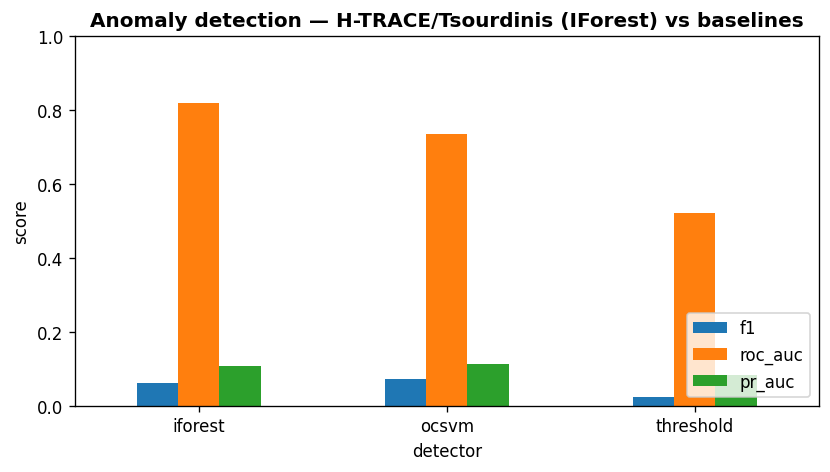

fig_forecast_comparison.png


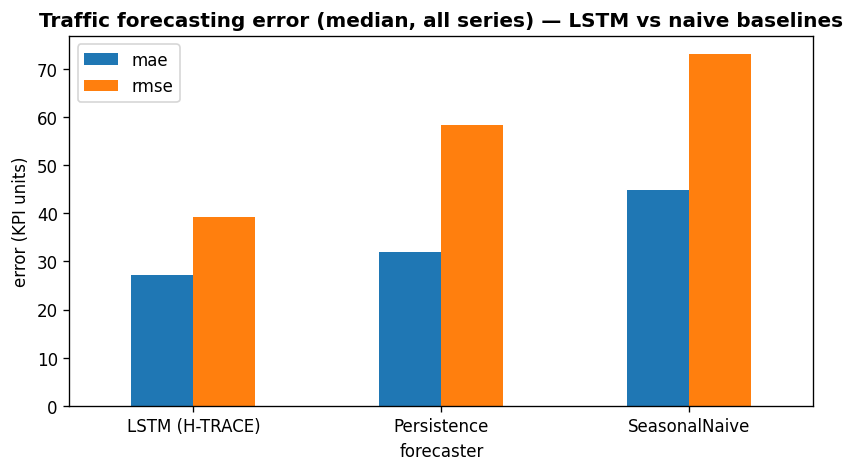

fig_forecast_by_kpi.png


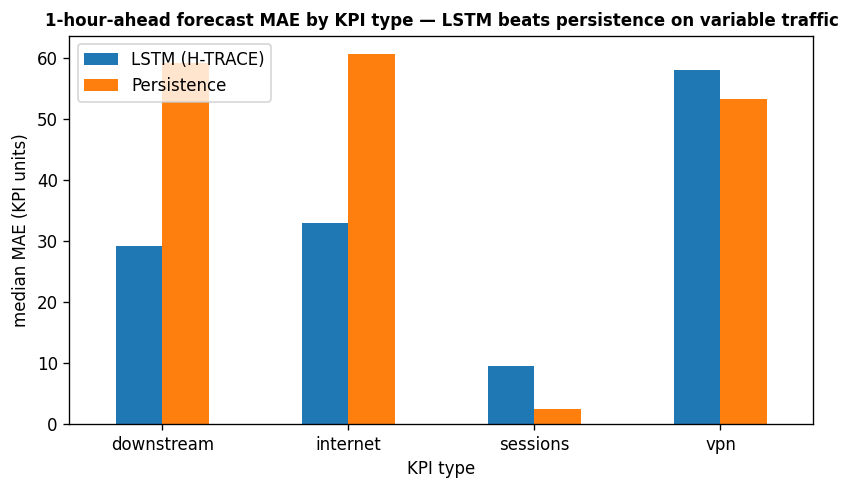

fig_safety_ablation.png


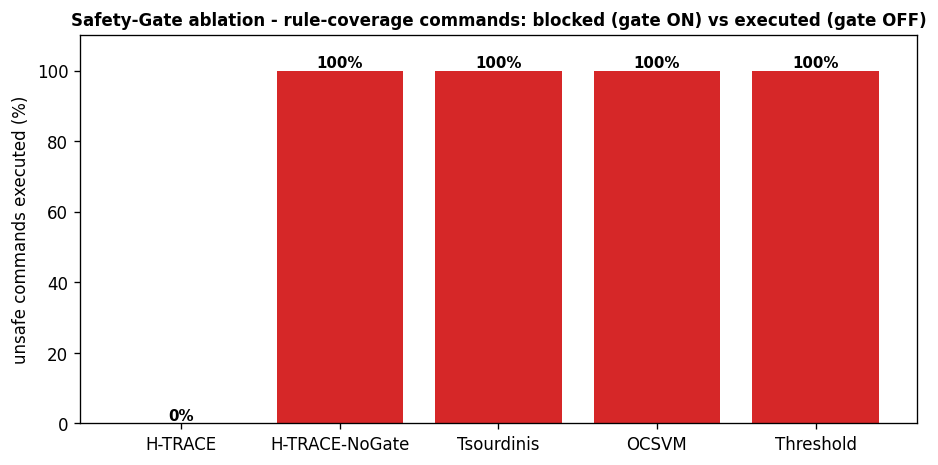

fig_latency.png


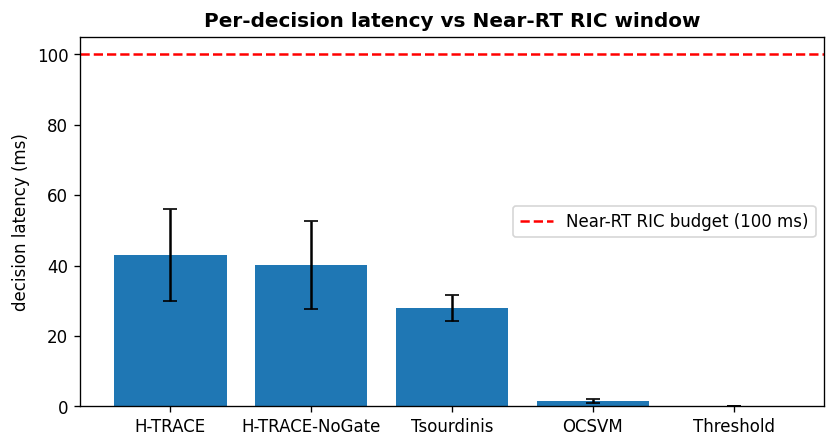

In [14]:
from IPython.display import Image, display
for fig in ['fig_detection_comparison.png','fig_forecast_comparison.png',
            'fig_forecast_by_kpi.png','fig_safety_ablation.png','fig_latency.png']:
    p = C.FIGURES_DIR / fig
    if p.exists():
        print(fig); display(Image(str(p)))